In [331]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.framework.ops import EagerTensor
from tensorflow.python.ops.resource_variable_ops import ResourceVariable
import time

In [332]:
tf.__version__

'2.16.1'

In [333]:
def layer_sizes(X, Y, num_hidden_units):
    
    num_input_units = X.element_spec.shape[0]
    num_output_units = Y.element_spec.shape[0]
    
    num_layer_units = [num_input_units] + num_hidden_units + [num_output_units]
    
    return num_layer_units

In [334]:
def initialize_parameters(num_layer_units):
    
    parameters = {}
    L = len(num_layer_units)
    
    initializer = tf.keras.initializers.GlorotNormal(seed=1) 
    
    for l in range(1, L):
        
        parameters[f"W{l}"] = tf.Variable(initializer(shape=(num_layer_units[l], num_layer_units[l-1])))
        parameters[f"b{l}"] = tf.Variable(initializer(shape=(num_layer_units[l], 1)))
        
    return parameters

In [335]:
def forward_propagation(X, parameters):
    
    L = len(parameters) // 2
    A = X
    
    for l in range(1, L):
        
        A_prev = A
        W = parameters[f"W{l}"]
        b = parameters[f"b{l}"]
        Z = tf.math.add(tf.linalg.matmul(W, A_prev), b)
        A = tf.keras.activations.relu(Z)

    A_prev = A
    W = parameters[f"W{L}"]
    b = parameters[f"b{L}"]
    ZL = tf.math.add(tf.linalg.matmul(W, A_prev), b)
    
    return ZL

In [336]:
def compute_cost(ZL, Y):
    
    cost = tf.reduce_sum(tf.keras.losses.categorical_crossentropy(tf.transpose(Y), tf.transpose(ZL), from_logits=True))
   
    return cost    

In [337]:
def train(X_train, Y_train, X_test, Y_test, num_hidden_units, num_epochs=1000, learning_rate=1e-4, minibatch_sizes=64, epsilon=100, print_cost=False, seed=1):

    train_costs = []
    test_costs = []
    
    num_layer_units = layer_sizes(X_train, Y_train, num_hidden_units)
    parameters = initialize_parameters(num_layer_units)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate)
    test_accuracy = tf.keras.metrics.CategoricalAccuracy()
    train_accuracy = tf.keras.metrics.CategoricalAccuracy()
   
    train_dataset = tf.data.Dataset.zip((X_train, Y_train))
    test_dataset = tf.data.Dataset.zip((X_test, Y_test))
    
    m = train_dataset.cardinality().numpy()
    train_minibatches = train_dataset.batch(minibatch_sizes).prefetch(8)
    test_minibatches = test_dataset.batch(minibatch_sizes).prefetch(8)
    
    for i in range(num_epochs):
        
        total_cost_train = 0.
        total_cost_test = 0.
        train_accuracy.reset_state()
        
        for (X_minibatch, Y_minibatch) in train_minibatches:

            with tf.GradientTape() as tape:
                
                ZL = forward_propagation(tf.transpose(X_minibatch), parameters)
                minibatch_cost = compute_cost(ZL, tf.transpose(Y_minibatch))
                
            train_accuracy.update_state(Y_minibatch, tf.transpose(ZL))
            trainable = list(parameters.values())
            grads = tape.gradient(minibatch_cost, trainable) 
            optimizer.apply_gradients(zip(grads, trainable))
            total_cost_train += minibatch_cost

        total_cost_train /= m
        train_costs.append(total_cost_train)
        
        if print_cost and i % epsilon == 0:
            print(f"Epoch: {i}: Cost: {total_cost_train}")
            print(f"Train Accuracy: {train_accuracy.result()}")

            for (X_minibatch, Y_minibatch) in test_minibatches:
                 
                ZL = forward_propagation(tf.transpose(X_minibatch), parameters)
                minibatch_cost = compute_cost(ZL, tf.transpose(Y_minibatch))
                total_cost_test += minibatch_cost
                test_accuracy.update_state(Y_minibatch, tf.transpose(ZL))
                
            total_cost_test /= m     
            test_costs.append(total_cost_test)
            print(f"Test Accuracy: {test_accuracy.result()}")
            test_accuracy.reset_state()
            
    return parameters, train_costs, test_costs       

In [338]:
train_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_signs.h5")
test_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_signs.h5")

X_train = tf.data.Dataset.from_tensor_slices(train_dataset['train_set_x'])
Y_train = tf.data.Dataset.from_tensor_slices(train_dataset['train_set_y'])

X_test = tf.data.Dataset.from_tensor_slices(test_dataset['test_set_x'])
Y_test = tf.data.Dataset.from_tensor_slices(test_dataset['test_set_y'])

In [339]:
print(X_train.element_spec.shape)

(64, 64, 3)


In [340]:
print(next(iter(X_train)))

tf.Tensor(
[[[227 220 214]
  [227 221 215]
  [227 222 215]
  ...
  [232 230 224]
  [231 229 222]
  [230 229 221]]

 [[227 221 214]
  [227 221 215]
  [228 221 215]
  ...
  [232 230 224]
  [231 229 222]
  [231 229 221]]

 [[227 221 214]
  [227 221 214]
  [227 221 215]
  ...
  [232 230 224]
  [231 229 223]
  [230 229 221]]

 ...

 [[119  81  51]
  [124  85  55]
  [127  87  58]
  ...
  [210 211 211]
  [211 212 210]
  [210 211 210]]

 [[119  79  51]
  [124  84  55]
  [126  85  56]
  ...
  [210 211 210]
  [210 211 210]
  [209 210 209]]

 [[119  81  51]
  [123  83  55]
  [122  82  54]
  ...
  [209 210 210]
  [209 210 209]
  [208 209 209]]], shape=(64, 64, 3), dtype=uint8)


In [341]:
unique_labels = set()
for element in Y_train:
    unique_labels.add(element.numpy())
print(unique_labels)

{0, 1, 2, 3, 4, 5}


2024-04-12 18:33:29.517182: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [342]:
def one_hot_encoding(label, C=6):
  
    one_hot = tf.reshape(tf.one_hot(label, depth=C, axis=0), shape=[C, ])
    
    return one_hot

In [343]:
Y_train = Y_train.map(one_hot_encoding)
Y_test = Y_test.map(one_hot_encoding)
print(Y_train.element_spec.shape)
print(Y_test.element_spec.shape)

(6,)
(6,)


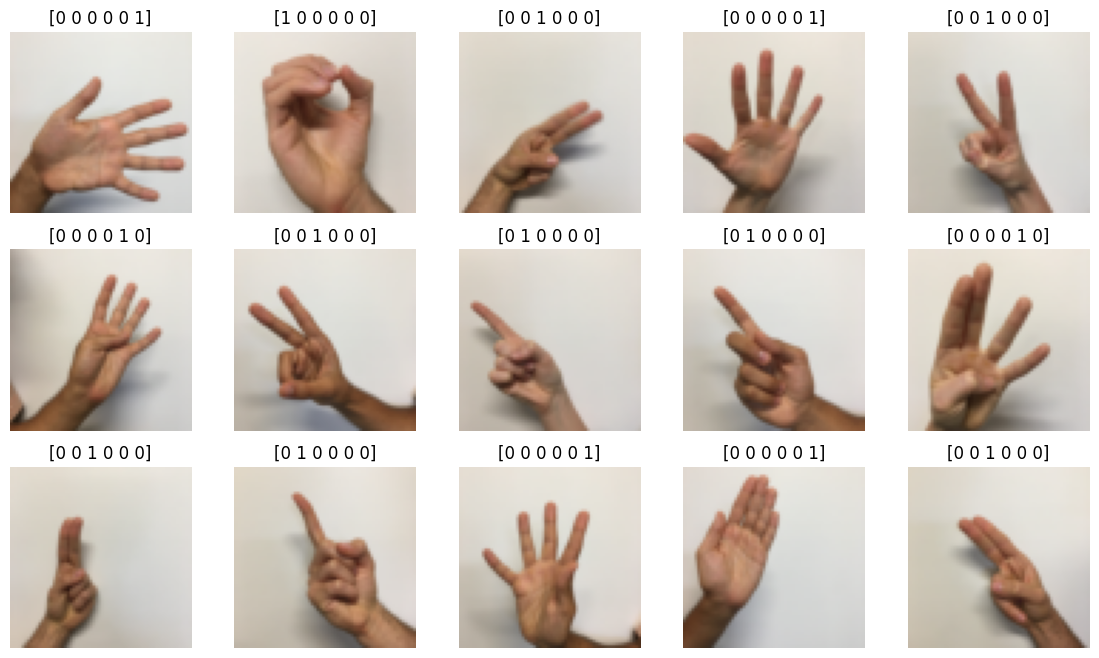

In [344]:
images_iter = iter(X_train)
labels_iter = iter(Y_train)
plt.figure(figsize=(14, 8))
for i in range(15):
    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(next(images_iter).numpy().astype("uint8"))
    plt.title(next(labels_iter).numpy().astype("uint8"))
    plt.axis("off")

In [345]:
def normalize(image):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, [-1,])
    return image

In [346]:
X_train = X_train.map(normalize)
X_test = X_test.map(normalize)

In [347]:
print(X_train.element_spec.shape)

(12288,)


In [348]:
print(next(iter(X_train)))

tf.Tensor([0.8901961  0.8627451  0.8392157  ... 0.8156863  0.81960785 0.81960785], shape=(12288,), dtype=float32)


In [352]:
parameters, train_costs, test_costs = train(
    X_train, 
    Y_train, 
    X_test, 
    Y_test, 
    [30, 20, 10], 
    num_epochs=300, 
    learning_rate=1e-4, 
    minibatch_sizes=32, 
    epsilon=30, 
    print_cost=True, 
    seed=1
)

2024-04-12 19:01:32.588380: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:01:32.643511: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 0: Cost: 1.8430637121200562
Train Accuracy: 0.1666666716337204
Test Accuracy: 0.1666666716337204


2024-04-12 19:01:34.277121: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:01:35.978213: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:01:37.761609: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:01:39.406584: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:01:41.184100: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:01:42.864618: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:01:44.737588: W tensorflow/core/framework/local_rendezvous.cc:404] L

Epoch: 30: Cost: 1.457603931427002
Train Accuracy: 0.4472222328186035
Test Accuracy: 0.4833333194255829


2024-04-12 19:02:27.231026: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:02:28.851315: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:02:30.521284: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:02:32.198842: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:02:33.855805: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:02:35.560547: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:02:37.398837: W tensorflow/core/framework/local_rendezvous.cc:404] L

...

2024-04-12 19:07:36.729361: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:07:38.413230: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:07:40.094147: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:07:41.780116: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:07:43.455791: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:07:45.192011: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:07:46.825798: W tensorflow/core/framework/local_rendezvous.cc:404] L

Epoch: 240: Cost: 0.44801270961761475
Train Accuracy: 0.8768518567085266
Test Accuracy: 0.7916666865348816


2024-04-12 19:08:28.464433: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:08:30.190048: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:08:31.892292: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:08:33.695287: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:08:35.387009: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:08:37.011845: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:08:38.694183: W tensorflow/core/framework/local_rendezvous.cc:404] L

Epoch: 270: Cost: 0.39739781618118286
Train Accuracy: 0.8935185074806213
Test Accuracy: 0.7916666865348816


2024-04-12 19:09:20.177337: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:09:21.867195: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:09:23.551019: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:09:25.240182: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:09:26.918418: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:09:28.598931: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-04-12 19:09:30.268253: W tensorflow/core/framework/local_rendezvous.cc:404] L

In [357]:
train_cost = []
test_cost = []

for cost in train_costs:
    train_cost.append(cost.numpy())

for cost in test_costs:
    test_cost.append(cost.numpy())
print(len(train_cost))
print(len(test_cost))

300
10


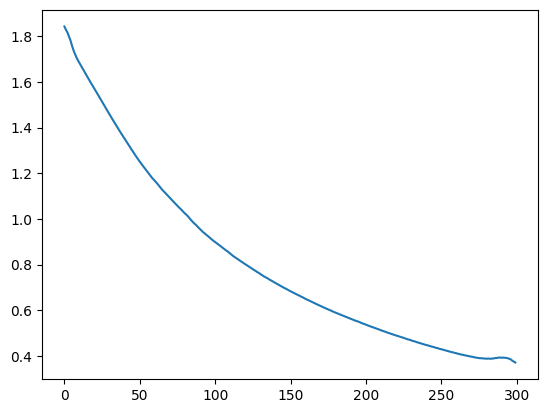

In [361]:
plt.plot(train_cost)
plt.show()

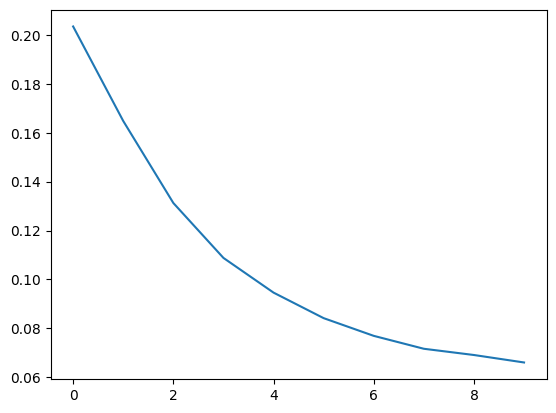

In [362]:
plt.plot(test_cost)
plt.show()